# Predição do preço do ouro com XGBoost

Notebook do experimento XGBoost usando `data/processed/gold_features.csv`.

Ideia:
- usar as mesmas features do experimento GRU/CNN
- manter horizontes `5, 15, 30`
- manter alvo em log-retorno acumulado
- avaliar com as mesmas métricas e visualizações do `lib`

Como XGBoost espera entrada tabular 2D, cada janela de 60 dias é achatada em um vetor.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from lib import (
    per_year_metrics,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_residuals,
    plot_return_predictions,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
    temporal_split,
)


REPO_ROOT = Path.cwd()

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost não está instalado neste ambiente. Instale o pacote para executar este notebook."
    ) from exc

SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"

np.random.seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("Repo root:", REPO_ROOT)

Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Carregamento

In [2]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    return [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]


df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features")
print(feature_cols)
df.head()

6177 linhas | 2000-08-30 -> 2025-04-14
19 features
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


,date,close,volume,log_ret_1,log_ret_5,log_ret_21,vol_5,vol_21,vol_ratio,dist_ma20,...,boll_b,drawdown_252,hl_range,close_pos,gap_open,fear_ratio,fear_ma5,y_5,y_15,y_30
0,2000-08-30,273.9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,NaN,0.000000,NaN,0.000365,-0.013231,0.009086
1,2000-08-31,278.3,0,0.015937,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012576,0.5,0.003280,0.000000,NaN,-0.018130,-0.023633,-0.021428
2,2000-09-01,277.0,0,-0.004682,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004682,0.062500,NaN,-0.014179,-0.010525,-0.020055
3,2000-09-05,275.8,2,-0.004342,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004342,0.111111,NaN,-0.010571,-0.006913,-0.017188
4,2000-09-06,274.2,0,-0.005818,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.005818,0.142857,0.063294,-0.005119,0.015201,-0.014325


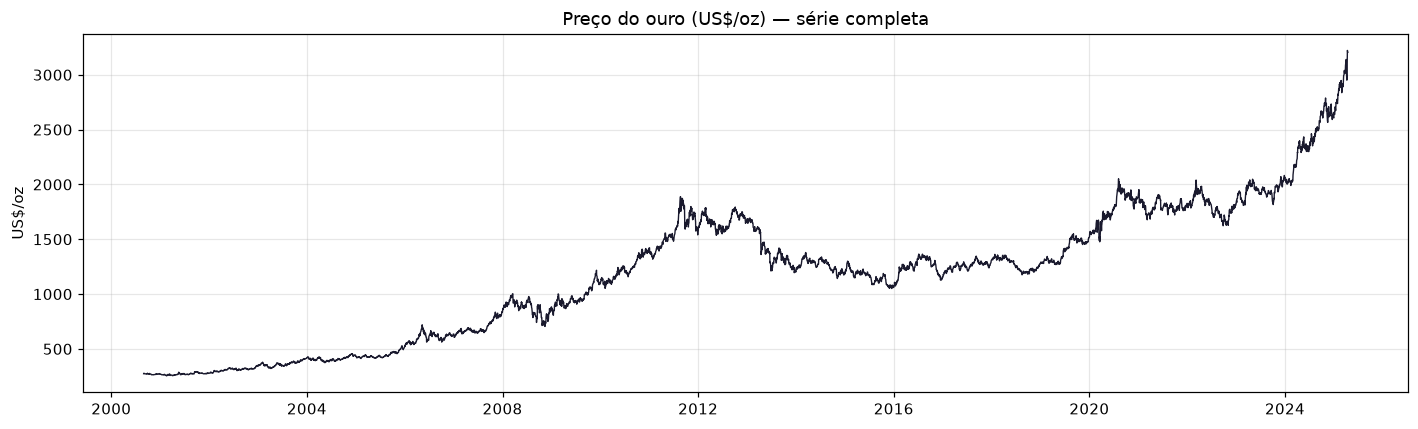

In [3]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
plt.show()

## Split temporal e janelas

In [4]:
splits = temporal_split(
    df=df,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    lookback=LOOKBACK,
    gap=GAP,
)

for name, ws in splits.items():
    d0 = df["date"].iloc[ws.idx[0]].date()
    d1 = df["date"].iloc[ws.idx[-1]].date()
    print(f"{name:>6}: {ws.X.shape} | {d0} -> {d1}")

treino: (4013, 60, 19) | 2001-11-29 -> 2017-11-27
   val: (837, 60, 19) | 2018-04-11 -> 2021-08-05
 teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


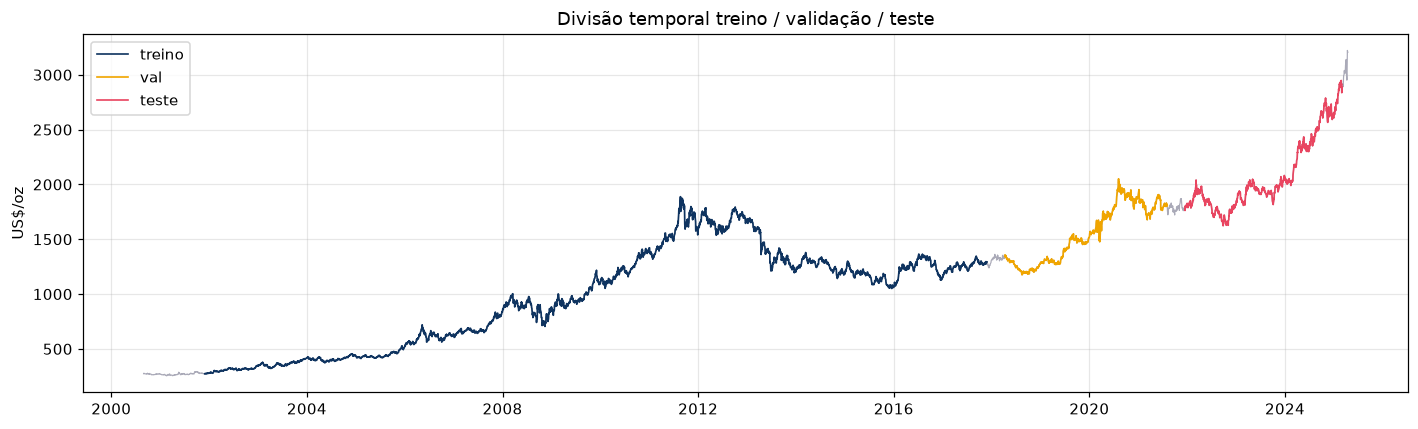

In [5]:
fig = plot_split_regions(
    df,
    {name: (ws.X, ws.Y, ws.prices, ws.idx) for name, ws in splits.items()},
    title="Divisão temporal treino / validação / teste",
    ylabel="US$/oz",
)
plt.show()

## Flatten das janelas para XGBoost

In [6]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1).astype(np.float32)


def make_window_feature_names(feature_cols: list[str], lookback: int) -> list[str]:
    names = []
    for lag in range(lookback - 1, -1, -1):
        for col in feature_cols:
            names.append(f"{col}_t-{lag}")
    return names


X = {name: flatten_windows(ws.X) for name, ws in splits.items()}
Y = {name: ws.Y.astype(np.float32) for name, ws in splits.items()}
Prices = {name: ws.prices for name, ws in splits.items()}
Idx = {name: ws.idx for name, ws in splits.items()}
window_feature_names = make_window_feature_names(feature_cols, LOOKBACK)

print("X treino:", X["treino"].shape)
print("Y treino:", Y["treino"].shape)
print("n window features:", len(window_feature_names))

X treino: (4013, 1140)
Y treino: (4013, 3)
n window features: 1140


## Modelo XGBoost

In [7]:
def build_model() -> XGBRegressor:
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        early_stopping_rounds=30,
    )


models = {}
preds = {}
rmse_curves = {}

for j, h in enumerate(HORIZONS):
    model = build_model()
    model.fit(
        X["treino"],
        Y["treino"][:, j],
        eval_set=[(X["treino"], Y["treino"][:, j]), (X["val"], Y["val"][:, j])],
        verbose=False,
    )
    models[h] = model
    rmse_curves[h] = model.evals_result()

for split in ["treino", "val", "teste"]:
    cols = []
    for h in HORIZONS:
        cols.append(models[h].predict(X[split]))
    preds[split] = np.column_stack(cols).astype(np.float32)

print("modelos treinados:", list(models))

modelos treinados: [5, 15, 30]


## Curvas de validação por horizonte

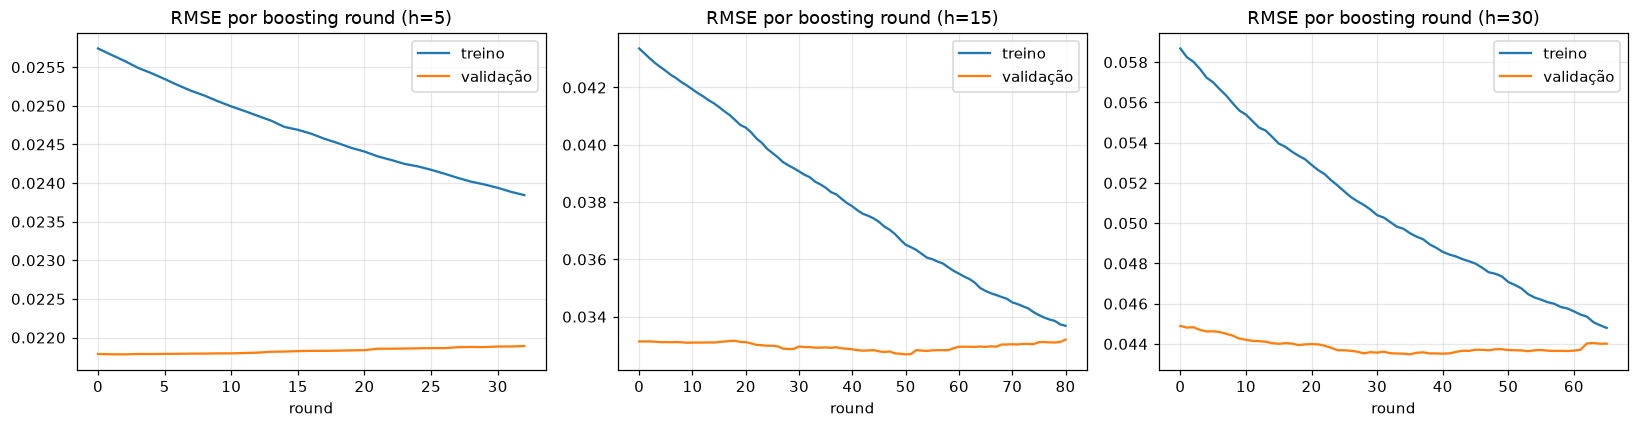

In [8]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4))
if len(HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    hist = rmse_curves[h]
    ax.plot(hist["validation_0"]["rmse"], label="treino")
    ax.plot(hist["validation_1"]["rmse"], label="validação")
    ax.set_title(f"RMSE por boosting round (h={h})")
    ax.set_xlabel("round")
    ax.legend()
plt.tight_layout()
plt.show()

## Avaliação

In [9]:
tbl = pd.concat(
    [
        regression_metrics(
            Y[split],
            preds[split],
            Prices[split],
            HORIZONS,
            split_name=split,
        )
        for split in ["treino", "val", "teste"]
    ],
    ignore_index=True,
)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino,5,18.684,26.936,1.939,55.943,0.991
1,treino,15,28.192,39.011,2.896,68.054,0.858
2,treino,30,38.669,53.654,3.907,70.022,0.858
3,val,5,24.332,36.000,1.516,57.109,0.989
4,val,15,40.097,54.005,2.510,56.750,0.990
5,val,30,57.648,70.504,3.638,55.556,0.982
6,teste,5,32.526,41.616,1.562,56.506,0.987
7,teste,15,57.248,71.820,2.739,57.745,0.957
8,teste,30,82.161,99.478,3.882,62.082,0.939


In [10]:
t = tbl[tbl["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE   RMSE  MAPE%  DirAcc%  MAE/naive
h                                          
5   32.53  41.62   1.56    56.51       0.99
15  57.25  71.82   2.74    57.74       0.96
30  82.16  99.48   3.88    62.08       0.94

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## Plots de desempenho

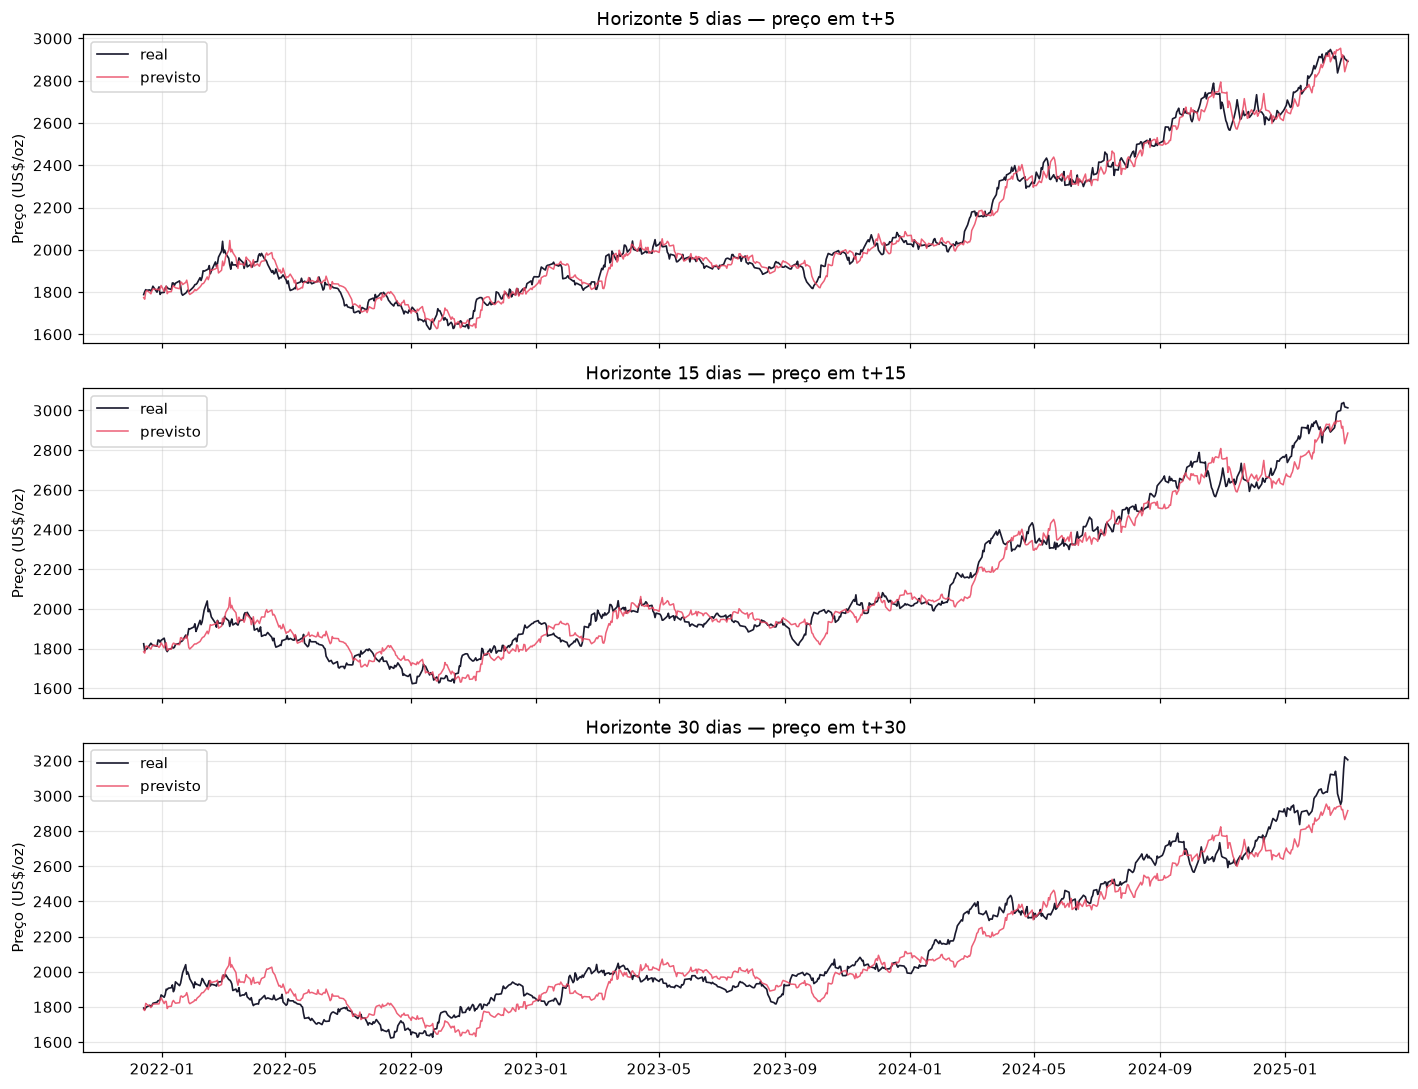

In [11]:
dates_te = df["date"].values[Idx["teste"]]
fig = plot_predicted_vs_actual(
    dates_te,
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
    ylabel="Preço (US$/oz)",
)
plt.show()

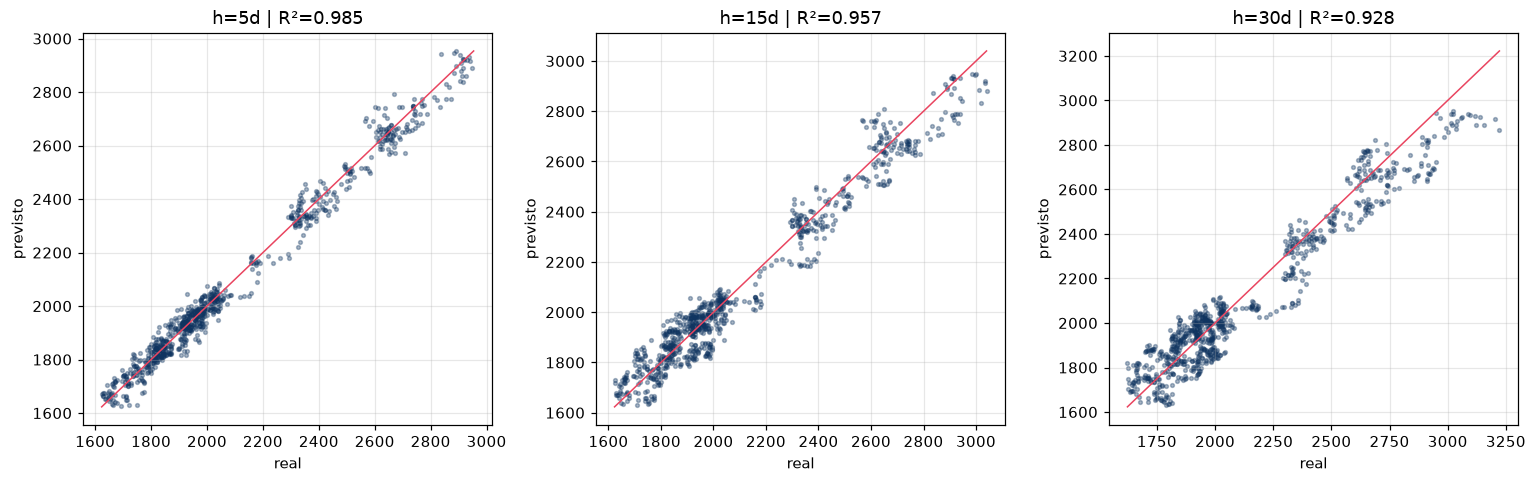

In [12]:
fig = plot_scatter(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
)
plt.show()

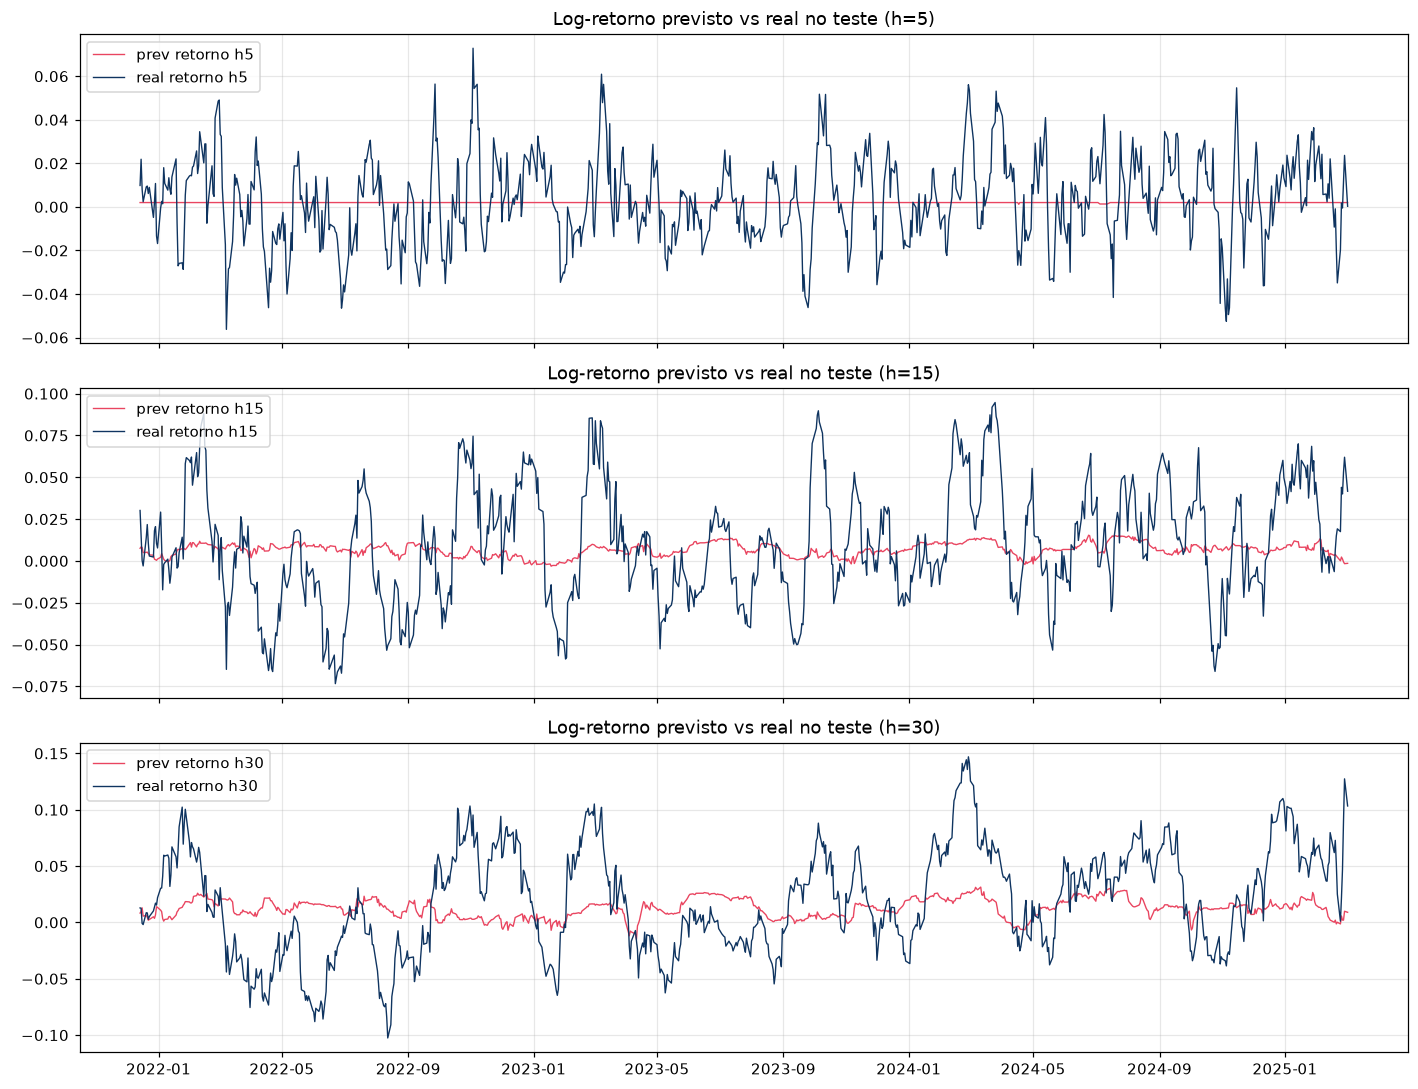

In [13]:
fig = plot_return_predictions(
    dates_te,
    Y["teste"],
    preds["teste"],
    HORIZONS,
)
plt.show()

In [14]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    dates_te,
    horizon_idx=h30_idx,
)
yearly

,DirAcc%,MAE/naive
ano,,
2021,84.615385,0.567314
2022,43.824701,1.084313
2023,55.200000,1.095302
2024,80.555556,0.789394
2025,95.121951,0.816848


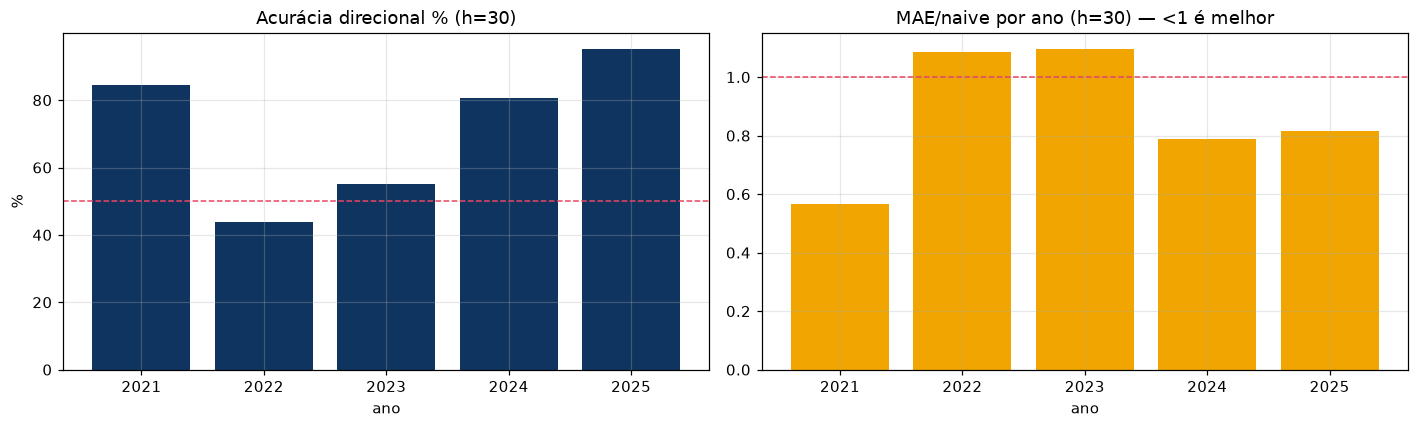

In [15]:
fig = plot_yearly_perf(yearly, horizon=30)
plt.show()

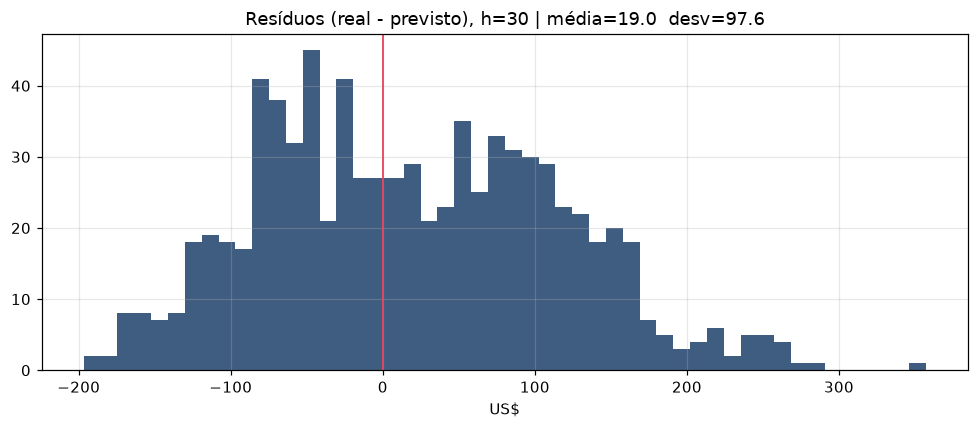

In [16]:
fig = plot_residuals(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    horizon_idx=h30_idx,
    horizon=30,
)
plt.show()

## Importância de features

In [17]:
imp = pd.DataFrame(
    {f"h{h}": models[h].feature_importances_ for h in HORIZONS},
    index=window_feature_names,
)
imp["mean"] = imp.mean(axis=1)
top_imp = imp.sort_values("mean", ascending=False).head(20)
top_imp

,h5,h15,h30,mean
ma_cross_t-1,0.016289,0.004394,0.005918,0.008867
vol_21_t-2,0.012575,0.007492,0.004014,0.008027
log_ret_21_t-1,0.013678,0.002379,0.006559,0.007539
ma_cross_t-2,0.013801,0.004281,0.003955,0.007346
ma_cross_t-30,0.011736,0.003865,0.004933,0.006845
ma_cross_t-11,0.009898,0.003233,0.006847,0.006660
ma_cross_t-10,0.013080,0.001416,0.005390,0.006629
vol_21_t-1,0.009026,0.004613,0.005641,0.006426
dist_ma50_t-1,0.008456,0.004390,0.005899,0.006249
vol_21_t-34,0.009206,0.006473,0.002654,0.006111


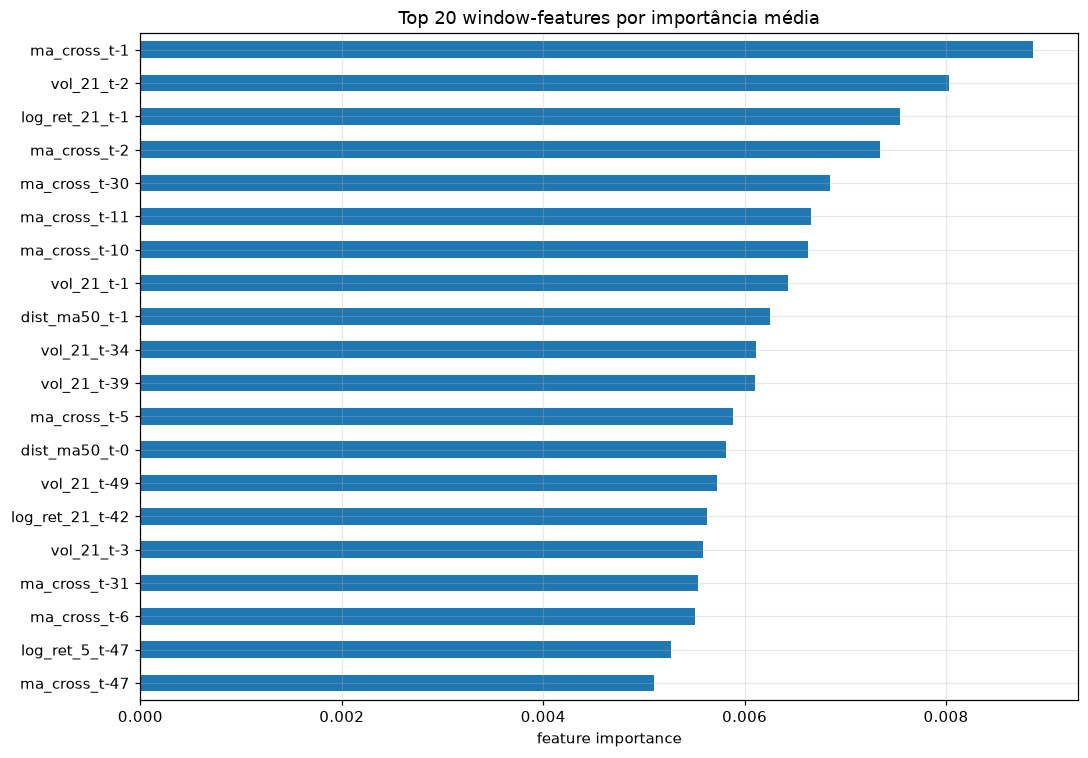

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
top_imp["mean"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 window-features por importância média")
ax.set_xlabel("feature importance")
plt.tight_layout()
plt.show()